In [1]:
import locale
def getpreferredencoding(do_setlocale = True):
  return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [3]:
from langchain_community.llms import LlamaCpp
from langchain_core.callbacks import CallbackManager, StreamingStdOutCallbackHandler
from langchain_core.prompts import PromptTemplate
#
n_gpu_layers = -1  # The number of layers to put on the GPU. The rest will be on the CPU. If you don't know how many layers there are, you can use -1 to move all to GPU.
n_batch = 512  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
#
# Callbacks support token-wise streaming
callback_manager = CallbackManager([StreamingStdOutCallbackHandler()])
#
# Make sure the model path is correct for your system!
model = LlamaCpp(
    model_path="zephyr-7b-beta.Q4_K_M.gguf",
    n_gpu_layers=n_gpu_layers,
    n_batch=n_batch,
    temperature=0.75,
    max_tokens=1000,
    top_p=1,
    n_ctx=35000,
    callback_manager=callback_manager,
    verbose=True,  # Verbose is required to pass to the callback manager
)

llama_model_loader: loaded meta data with 21 key-value pairs and 291 tensors from zephyr-7b-beta.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = huggingfaceh4_zephyr-7b-beta
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_loader: - kv   7:                 llama.attention.h

llama_model_loader: - kv  14:                      tokenizer.ggml.scores arr[f32,32000]   = [0.000000, 0.000000, 0.000000, 0.0000...
llama_model_loader: - kv  15:                  tokenizer.ggml.token_type arr[i32,32000]   = [2, 3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...
llama_model_loader: - kv  16:                tokenizer.ggml.bos_token_id u32              = 1
llama_model_loader: - kv  17:                tokenizer.ggml.eos_token_id u32              = 2
llama_model_loader: - kv  18:            tokenizer.ggml.unknown_token_id u32              = 0
llama_model_loader: - kv  19:            tokenizer.ggml.padding_token_id u32              = 2
llama_model_loader: - kv  20:               general.quantization_version u32              = 2
llama_model_loader: - type  f32:   65 tensors
llama_model_loader: - type q4_K:  193 tensors
llama_model_loader: - type q6_K:   33 tensors
llm_load_vocab: control token:      2 '</s>' is not marked as EOG
llm_load_vocab: control token:      1 '<s>' is not marked as

In [4]:
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
#
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

embd = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # set True for cosine similarity
)

C:\Users\hasee\AppData\Local\Temp\ipykernel_16352\403431965.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embd = HuggingFaceEmbeddings(
c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import matplotlib.pyplot as plt
import tiktoken
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

url = "https://python.langchain.com/docs/expression_language/"
loader = RecursiveUrlLoader(url, max_depth=20, extractor = lambda x: Soup(x, "html.parser").text)
docs = loader.load()
docs_texts = [doc.page_content for doc in docs]


<function matplotlib.pyplot.show(close=None, block=None)>

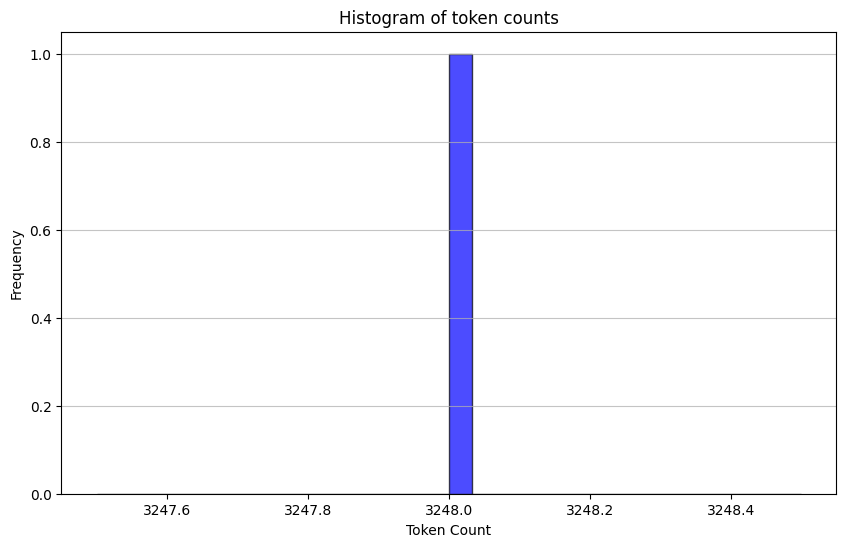

In [6]:
counts = [num_tokens_from_string(doc, "cl100k_base") for doc in docs_texts]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title("Histogram of token counts")
plt.ylabel("Frequency")
plt.xlabel("Token Count")
plt.grid(axis='y', alpha=0.75)
plt.show

In [7]:
d_sorted = sorted(docs, key=lambda x: x.metadata['source'])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join([doc.page_content for doc in d_reversed])
print(f'Num tokens in all context: {num_tokens_from_string(concatenated_content, "cl100k_base")}')

Num tokens in all context: 3248


In [8]:
print(concatenated_content)






LangChain Expression Language (LCEL) | 🦜️🔗 LangChain






Skip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow to use few sho

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size = 1000
text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=0)
texts_split = text_splitter.split_text(concatenated_content)
print(f"Num chunks: {len(texts_split)}")


Num chunks: 21


In [10]:
global_embeddings = [embd.embed_query(chunk) for chunk in texts_split]
print(f"Length of 1 global embedding: {len(global_embeddings[0])}")

Length of 1 global embedding: 384


c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[ 8.638478   -0.97886354]


<function matplotlib.pyplot.show(close=None, block=None)>

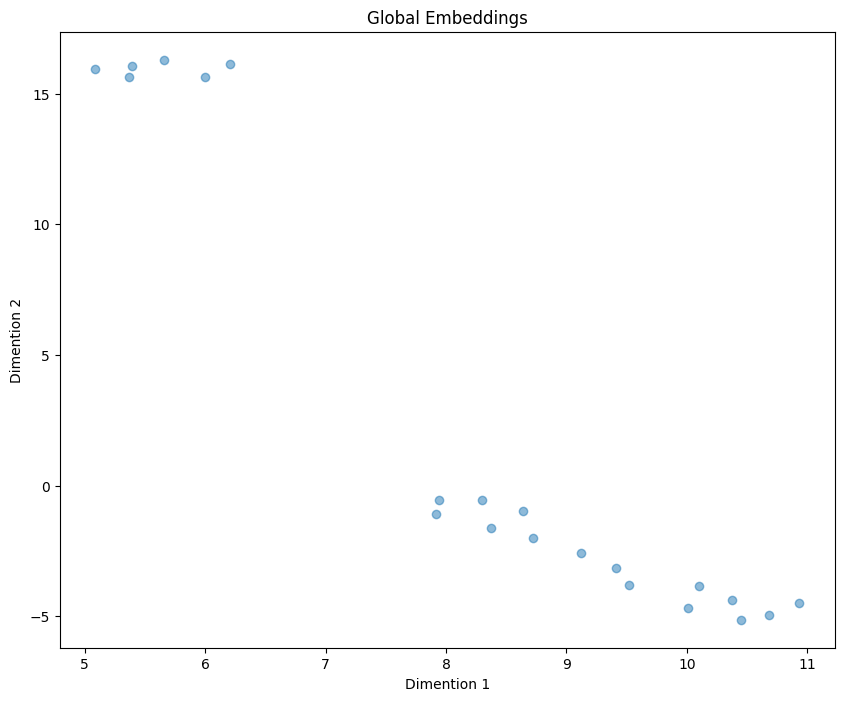

In [11]:
import matplotlib.pyplot as plt
from typing import Optional
import numpy as np
import umap

def reduce_cluster_embeddings(
        embeddings: np.ndarray,
        dim: int,
        n_neighbors: Optional[int]=None,
        metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(n_neighbors=n_neighbors, n_components=dim, metric=metric).fit_transform(embeddings)

dim = 2
global_embeddings_reduced = reduce_cluster_embeddings(global_embeddings, dim)
print(global_embeddings_reduced[0])

plt.figure(figsize=(10, 8))
plt.scatter(global_embeddings_reduced[:, 0], global_embeddings_reduced[:, 1], alpha=0.5)
plt.title("Global Embeddings")
plt.xlabel("Dimention 1")
plt.ylabel("Dimention 2")
plt.show

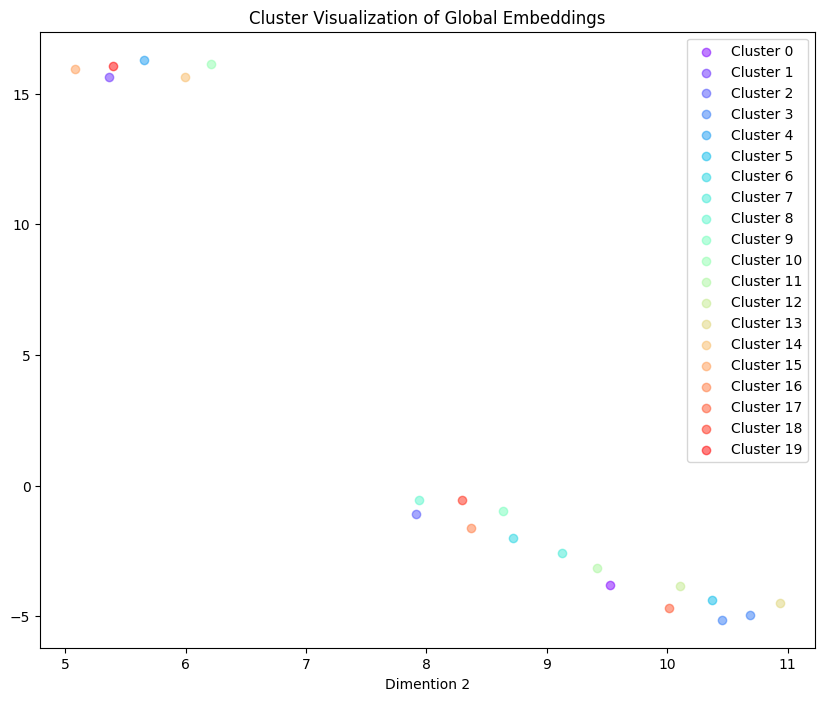

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture

def get_optimal_clusters(embeddings: np.ndarray, max_clusters: int = 50, random_state: int=1234):
    max_clusters = min(max_clusters, len(embeddings))
    bics = [GaussianMixture(n_components=n, random_state=random_state).fit(embeddings).bic(embeddings) for n in range(1, max_clusters)]
    return np.argmin(bics) + 1

def gmm_clustering(embeddings: np.ndarray, threshold: float, random_state: int =0):
    n_clusters = get_optimal_clusters(embeddings=embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state).fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters

labels, _ = gmm_clustering(global_embeddings_reduced, threshold=0.5)

plot_labels = np.array([label[0] if len(label) > 0 else -1 for label in labels])
plt.figure(figsize=(10,8))

unique_labels = np.unique(plot_labels)
colors = plt.cm.rainbow(np.linspace(0,1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = plot_labels == label
    plt.scatter(global_embeddings_reduced[mask, 0], global_embeddings_reduced[mask, 1], color=color, label=f'Cluster {label}', alpha=0.5)

plt.title("Cluster Visualization of Global Embeddings")
plt.xlabel("Dimention 1")
plt.xlabel("Dimention 2")
plt.legend()
plt.show()

In [13]:
import pandas as pd

simple_labels = [label[0] if len(label) > 0 else -1 for label in labels]

df = pd.DataFrame({
    'Text': texts_split,
    'Embedding': list(global_embeddings_reduced),
    'Cluster' : simple_labels
})

print(df.head(3))

                                                Text                Embedding  \
0  LangChain Expression Language (LCEL) | 🦜️🔗 Lan...  [8.638478, -0.97886354]   
1  Skip to main contentIntegrationsAPI ReferenceM...    [5.658555, 16.297796]   
2  install LangChain packagesHow to add examples ...   [5.3941364, 16.069197]   

   Cluster  
0        9  
1        4  
2       19  


In [14]:
def foramt_cluster_texts(df):
    clustered_text = {}
    for cluster in df['Cluster'].unique():
        cluster_texts = df[df['Cluster'] == cluster]['Text'].tolist()
        clustered_text[cluster] = "---".join(cluster_texts)
    return clustered_text

print(foramt_cluster_texts(df=df))

{9: 'LangChain Expression Language (LCEL) | 🦜️🔗 LangChain', 4: 'Skip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow to use few sho

# Helper Function

In [15]:
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import umap
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 224

def global_cluster_embeddings(
        embeddings: np.ndarray,
        dim: int,
        n_neighbors: Optional[int] = None,
        metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

def local_cluster_embeddings(
        embeddings: np.ndarray, dim: int, num_neighbours: int=10, metric: str="cosine"
) -> np.ndarray:
    return umap.UMAP(
        n_neighbors=num_neighbours, n_components=dim, metric=metric).fit_transform(embeddings)

def get_optimal_clusters(
        embeddings: np.ndarray, max_clusters: int=50, random_state: int = RANDOM_SEED, 
) -> int:
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arrange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]

def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    n_clusters = get_optimal_clusters(embeddings=embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict(embeddings)
    labels = [np.where(prob>threshold)[0] for prob in probs]
    return labels, n_clusters

def perform_clustering(
        embeddings: np.ndarray,
        dim:int,
        threshold: float,
) -> list[np.ndarray]:
    if len(embeddings) <=dim + 1:
        return [np.array([0]) for _ in range(len(embeddings))]
    
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
    global_clusters, n_global_clusters = GMM_cluster(reduced_embeddings_global, threshold)

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    for i in range(n_global_clusters):
        global_cluster_embeddings_ = embeddings[np.array([i in gc for gc in global_clusters])]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim+1:
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
        else:
            reduced_embeddings_local = local_cluster_embeddings(global_cluster_embeddings_, dim)
            local_clusters, n_local_clusters = GMM_cluster(reduced_embeddings_local, threshold)

        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[global_cluster_embeddings_[np.array([j in lc for lc in local_clusters])]]
            indices = np.where(
                embeddings == local_cluster_embeddings_[:, None].all(-1))[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(all_local_clusters[idx], j + total_clusters)
        
        total_clusters += n_local_clusters

    return all_local_clusters

In [22]:
def embed(texts):
    """
    Generate embeddings for a list of text documents.

    This function assumes the existence of an `embd` object with a method `embed_documents`
    that takes a list of texts and returns their embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be embedded.

    Returns:
    - numpy.ndarray: An array of embeddings for the given text documents.
    """
    text_embeddings = embd.embed_documents(texts)
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np


def embed_cluster_texts(texts):
    """
    Embeds a list of texts and clusters them, returning a DataFrame with texts, their embeddings, and cluster labels.

    This function combines embedding generation and clustering into a single step. It assumes the existence
    of a previously defined `perform_clustering` function that performs clustering on the embeddings.

    Parameters:
    - texts: List[str], a list of text documents to be processed.

    Returns:
    - pandas.DataFrame: A DataFrame containing the original texts, their embeddings, and the assigned cluster labels.
    """
    text_embeddings_np = embed(texts)  # Generate embeddings
    cluster_labels = perform_clustering(
        text_embeddings_np, 10, 0.1
    )  # Perform clustering on the embeddings
    df = pd.DataFrame()  # Initialize a DataFrame to store the results
    df["text"] = texts  # Store original texts
    df["embd"] = list(text_embeddings_np)  # Store embeddings as a list in the DataFrame
    df["cluster"] = cluster_labels  # Store cluster labels
    return df


def fmt_txt(df: pd.DataFrame) -> str:
    """
    Formats the text documents in a DataFrame into a single string.

    Parameters:
    - df: DataFrame containing the 'text' column with text documents to format.

    Returns:
    - A single string where all text documents are joined by a specific delimiter.
    """
    unique_txt = df["text"].tolist()
    return "--- --- \n --- --- ".join(unique_txt)


def embed_cluster_summarize_texts(
    texts: List[str], level: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Embeds, clusters, and summarizes a list of texts. This function first generates embeddings for the texts,
    clusters them based on similarity, expands the cluster assignments for easier processing, and then summarizes
    the content within each cluster.

    Parameters:
    - texts: A list of text documents to be processed.
    - level: An integer parameter that could define the depth or detail of processing.

    Returns:
    - Tuple containing two DataFrames:
      1. The first DataFrame (`df_clusters`) includes the original texts, their embeddings, and cluster assignments.
      2. The second DataFrame (`df_summary`) contains summaries for each cluster, the specified level of detail,
         and the cluster identifiers.
    """

    # Embed and cluster the texts, resulting in a DataFrame with 'text', 'embd', and 'cluster' columns
    df_clusters = embed_cluster_texts(texts)

    # Prepare to expand the DataFrame for easier manipulation of clusters
    expanded_list = []

    # Expand DataFrame entries to document-cluster pairings for straightforward processing
    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text": row["text"], "embd": row["embd"], "cluster": cluster}
            )

    # Create a new DataFrame from the expanded list
    expanded_df = pd.DataFrame(expanded_list)

    # Retrieve unique cluster identifiers for processing
    all_clusters = expanded_df["cluster"].unique()

    print(f"--Generated {len(all_clusters)} clusters--")

    # Summarization
    template = """Here is a sub-set of LangChain Expression Langauge doc.

    LangChain Expression Langauge provides a way to compose chain in LangChain.

    Give a detailed summary of the documentation provided.

    Documentation:
    {context}
    """
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | model | StrOutputParser()

    # Format text within each cluster for summarization
    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        formatted_txt = fmt_txt(df_cluster)
        summaries.append(chain.invoke({"context": formatted_txt}))

    # Create a DataFrame to store summaries with their corresponding cluster and level
    df_summary = pd.DataFrame(
        {
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        }
    )

    return df_clusters, df_summary


def recursive_embed_cluster_summarize(
    texts: List[str], level: int = 1, n_levels: int = 3
) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Recursively embeds, clusters, and summarizes texts up to a specified level or until
    the number of unique clusters becomes 1, storing the results at each level.

    Parameters:
    - texts: List[str], texts to be processed.
    - level: int, current recursion level (starts at 1).
    - n_levels: int, maximum depth of recursion.

    Returns:
    - Dict[int, Tuple[pd.DataFrame, pd.DataFrame]], a dictionary where keys are the recursion
      levels and values are tuples containing the clusters DataFrame and summaries DataFrame at that level.
    """
    results = {}  # Dictionary to store results at each level

    # Perform embedding, clustering, and summarization for the current level
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)

    # Store the results of the current level
    results[level] = (df_clusters, df_summary)

    # Determine if further recursion is possible and meaningful
    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        # Use summaries as the input texts for the next level of recursion
        new_texts = df_summary["summaries"].tolist()
        next_level_results = recursive_embed_cluster_summarize(
            new_texts, level + 1, n_levels
        )

        # Merge the results from the next level into the current results dictionary
        results.update(next_level_results)

    return results


In [23]:
leaf_texts = docs_texts
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels = 3)

--Generated 1 clusters--

<|user|>
Can you provide me with more information on how to use LCEL to compose a chain with complex state management, branching, and cycles? And when should I consider using LangGraph instead of LCEL for these types of applications?

llama_perf_context_print:        load time =  352627.10 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  3884 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /    56 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  367111.22 ms /  3940 tokens


In [24]:
all_texts = leaf_texts.copy()

for level in sorted(results.keys()):
    summaries = results[level][1]["summaries"].tolist()
    all_texts.extend(summaries)

print(all_texts)

['\n\n\n\n\nLangChain Expression Language (LCEL) | 🦜️🔗 LangChain\n\n\n\n\n\n\nSkip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow 

In [25]:
vector_store = Chroma.from_texts(texts=all_texts, embedding=embd)
retriever = vector_store.as_retriever()

In [33]:
from langchain import hub
from langchain_core.runnables import RunnablePassthrough

# Prompt
prompt = hub.pull("rlm/rag-prompt")


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\langsmith\client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [34]:
# Question
response =rag_chain.invoke("What is LCEL?")
print(str(response))

Number of requested results 4 is greater than number of elements in index 2, updating n_results = 2
Llama.generate: 3 prefix-match hit, remaining 3957 prompt tokens to eval


 LCEL (LangChain Expression Language) is a declarative approach to building new Runnables from existing Runnables in LangChain. It allows for optimized parallel execution, guaranteed async support, and simplified streaming of output. It is recommended for simpler orchestration tasks but should not be used for complex state management, branching, cycles, or multiple agents. For more complex chains, LangGraph is recommended instead as it enables defining complex orchestration logic that is more readable and maintainable while still allowing the use of LCEL within individual nodes. Legacy chains such as LLMChain and ConversationalRetrievalChain are being replaced by LCEL for consistency in behavior and customization.

llama_perf_context_print:        load time =  352627.10 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  3957 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   147 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  483390.89 ms /  4104 tokens


 LCEL (LangChain Expression Language) is a declarative approach to building new Runnables from existing Runnables in LangChain. It allows for optimized parallel execution, guaranteed async support, and simplified streaming of output. It is recommended for simpler orchestration tasks but should not be used for complex state management, branching, cycles, or multiple agents. For more complex chains, LangGraph is recommended instead as it enables defining complex orchestration logic that is more readable and maintainable while still allowing the use of LCEL within individual nodes. Legacy chains such as LLMChain and ConversationalRetrievalChain are being replaced by LCEL for consistency in behavior and customization.
